# 0. Setup e imports

In [16]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

DATA_PATH    = "../data/raw/transaction_data.parquet"
PRODUCT_PATH = "../data/raw/product.parquet"
GRAPH_DIR    = "../outputs/graphs"

## 1. Raw data inspection

In [17]:
raw = pd.read_parquet(DATA_PATH).astype({"BASKET_ID": int, "PRODUCT_ID": int, "DAY": int})
print(f"Shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
print(f"Day range: {raw['DAY'].min()} → {raw['DAY'].max()}  ({raw['DAY'].nunique()} unique days)")
print(f"Unique baskets: {raw['BASKET_ID'].nunique():,}")
print(f"Unique products: {raw['PRODUCT_ID'].nunique():,}")
print(f"\nMissing values:\n{raw.isnull().sum()[raw.isnull().sum() > 0]}")
raw.head()

Shape: (2595732, 12)
Columns: ['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO', 'COUPON_DISC', 'COUPON_MATCH_DISC']
Day range: 1 → 711  (711 unique days)
Unique baskets: 276,484
Unique products: 92,339

Missing values:
Series([], dtype: int64)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


Basket size stats (raw):
count    276484.000000
mean          9.388362
std          12.283792
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
max         168.000000
Name: PRODUCT_ID, dtype: float64

Single-item baskets: 60,045  (21.7%)


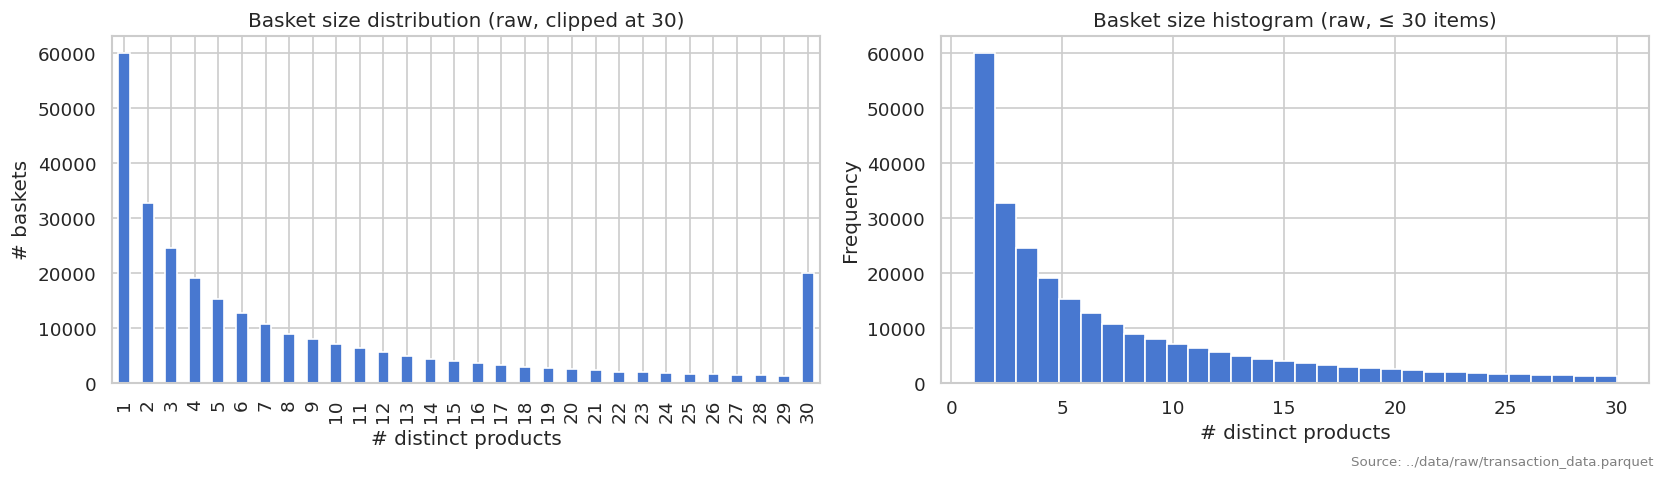

In [18]:
# Basket size distribution (before filtering)
basket_sizes_raw = raw.groupby("BASKET_ID")["PRODUCT_ID"].nunique()
print(f"Basket size stats (raw):\n{basket_sizes_raw.describe()}\n")
print(f"Single-item baskets: {(basket_sizes_raw == 1).sum():,}  ({100*(basket_sizes_raw==1).mean():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
basket_sizes_raw.clip(upper=30).value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Basket size distribution (raw, clipped at 30)")
axes[0].set_xlabel("# distinct products")
axes[0].set_ylabel("# baskets")

basket_sizes_raw[basket_sizes_raw <= 30].plot(kind="hist", bins=30, ax=axes[1])
axes[1].set_title("Basket size histogram (raw, ≤ 30 items)")
axes[1].set_xlabel("# distinct products")
fig.text(0.99, 0.01, f"Source: {DATA_PATH}", ha="right", fontsize=8, color="gray")
plt.tight_layout()

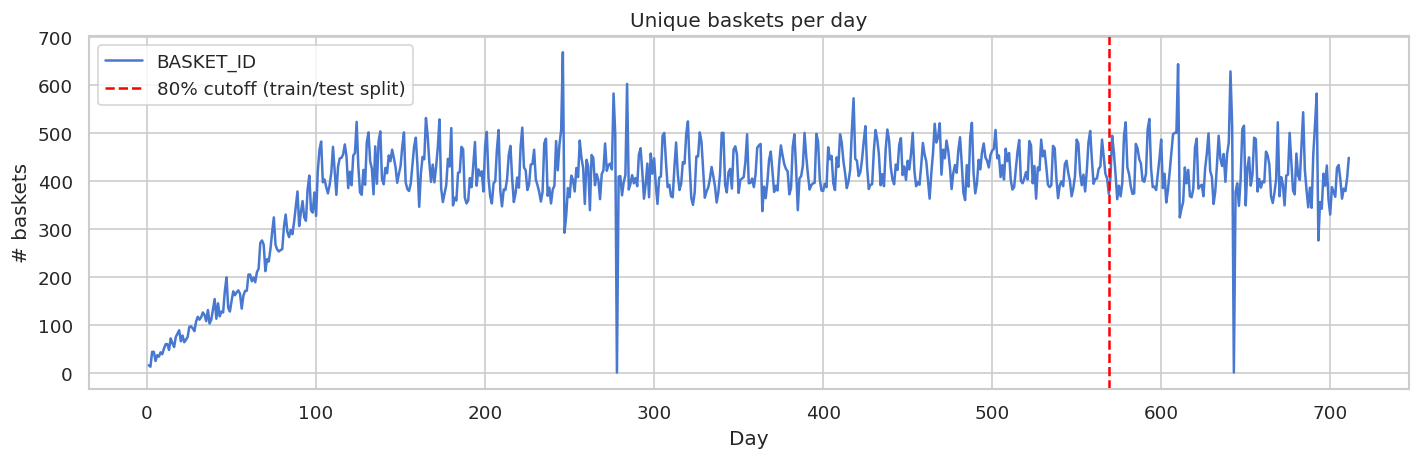

In [19]:
# Transactions per day — check for temporal coverage gaps
txn_per_day = raw.groupby("DAY")["BASKET_ID"].nunique()
fig, ax = plt.subplots(figsize=(12, 4))
txn_per_day.plot(ax=ax)
ax.set_title("Unique baskets per day")
ax.set_xlabel("Day")
ax.set_ylabel("# baskets")
ax.axvline(pd.Series(txn_per_day.index).quantile(0.8), color="red", linestyle="--", label="80% cutoff (train/test split)")
ax.legend()
plt.tight_layout()

## 2. Preprocessing pipeline output

In [20]:
from src.preprocessing import load_transactions, clean_transactions, split_by_day

df = load_transactions(DATA_PATH, product_parquet_path=PRODUCT_PATH)
df, product_index, product_meta = clean_transactions(df, min_support=50)
train_baskets, test_baskets, cutoff_day = split_by_day(df, train_fraction=0.8)

n_products = len(product_index)
print(f"Vocabulary size (products after filtering): {n_products:,}")
print(f"Train baskets: {len(train_baskets):,}")
print(f"Test  baskets: {len(test_baskets):,}")
print(f"\nproduct_meta columns: {list(product_meta.columns)}")
product_meta.head()

Vocabulary size (products after filtering): 10,370
Train baskets: 201,309
Test  baskets: 55,087

product_meta columns: ['product_id', 'commodity_desc', 'sub_commodity_desc', 'department', 'brand']


,product_id,commodity_desc,sub_commodity_desc,department,brand
product_idx,,,,,
0,201704,TROPICAL FRUIT,BANANAS,PRODUCE,National
1,279994,SALAD BAR,SALAD BAR FRESH FRUIT,SALAD BAR,National
2,397896,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,KIOSK-GAS,Private
3,818980,BEANS - CANNED GLASS & MW,PREPARED BEANS - BAKED W/PORK,GROCERY,National
4,818981,COLD CEREAL,ALL FAMILY CEREAL,GROCERY,National


In [21]:
# Sanity checks: no leakage — train and test baskets share no basket_id
train_ids = df[df["basket_id"].isin(
    df.groupby("basket_id")["day"].min().pipe(lambda s: s[s <= s.quantile(0.8)]).index
)]["basket_id"].unique()
test_ids = df[~df["basket_id"].isin(train_ids)]["basket_id"].unique()
overlap = set(train_ids) & set(test_ids)
assert len(overlap) == 0, f"Leakage detected: {len(overlap)} baskets in both splits"
print("No basket ID overlap between train and test.")

# Basket size distribution after cleaning
train_sizes = [len(b) for b in train_baskets]
test_sizes  = [len(b) for b in test_baskets]
print(f"\nTrain basket size — mean: {np.mean(train_sizes):.2f}, median: {np.median(train_sizes):.0f}, max: {max(train_sizes)}")
print(f"Test  basket size — mean: {np.mean(test_sizes):.2f},  median: {np.median(test_sizes):.0f},  max: {max(test_sizes)}")

No basket ID overlap between train and test.

Train basket size — mean: 7.97, median: 4, max: 142
Test  basket size — mean: 8.30,  median: 4,  max: 129


Top 10 most frequent products:
  TROPICAL FRUIT                            29,778 baskets
  COUPON/MISC ITEMS                         19,820 baskets
  FLUID MILK PRODUCTS                       14,430 baskets
  FLUID MILK PRODUCTS                       12,542 baskets
  FLUID MILK PRODUCTS                       9,826 baskets
  EGGS                                      9,126 baskets
  FLUID MILK PRODUCTS                       7,315 baskets
  BAKED BREAD/BUNS/ROLLS                    6,904 baskets
  BAKED BREAD/BUNS/ROLLS                    6,138 baskets
  BAKED BREAD/BUNS/ROLLS                    5,505 baskets


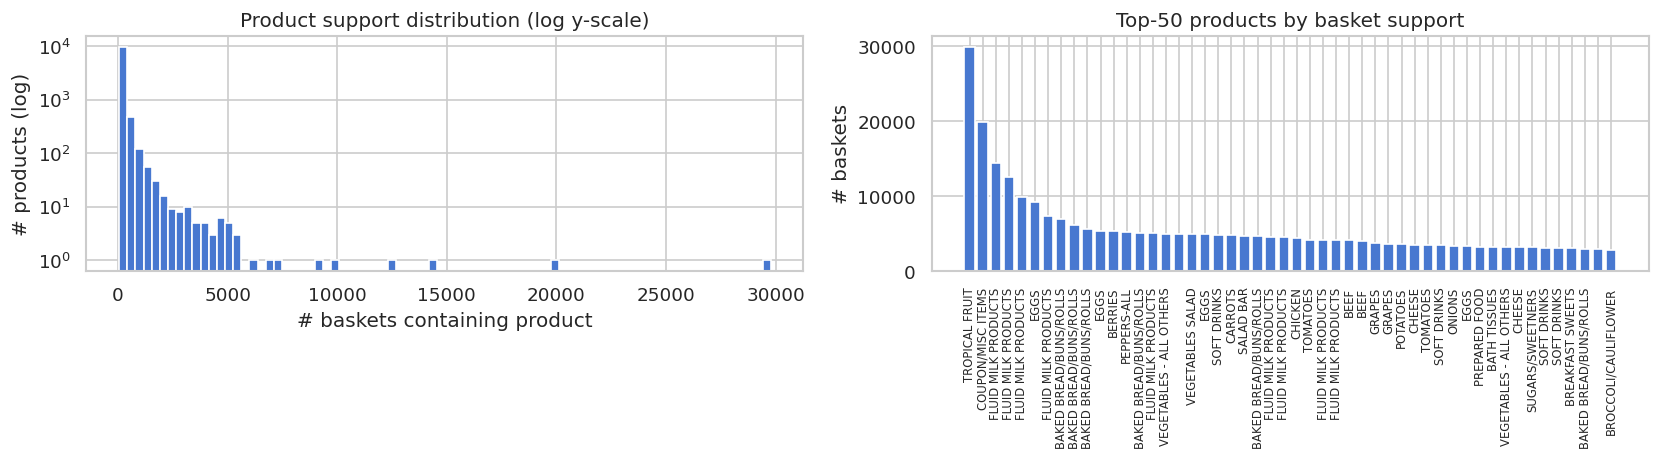

In [22]:
# Product support distribution (how many baskets each product appears in)
product_support = df.groupby("product_id")["basket_id"].nunique().sort_values(ascending=False)

# Enrich with product names for display
idx_to_pid = product_meta["product_id"].to_dict()          # product_idx → product_id
pid_to_name = (
    product_meta.reset_index()
    .set_index("product_id")["commodity_desc"]
    .to_dict()
)
top50_support = product_support.head(50)
top50_labels = [pid_to_name.get(pid, str(pid)) for pid in top50_support.index]

print(f"Top 10 most frequent products:")
for pid, count in product_support.head(10).items():
    print(f"  {pid_to_name.get(pid, pid):40s}  {count:,} baskets")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
product_support.plot(kind="hist", bins=80, log=True, ax=axes[0])
axes[0].set_title("Product support distribution (log y-scale)")
axes[0].set_xlabel("# baskets containing product")
axes[0].set_ylabel("# products (log)")

axes[1].bar(range(len(top50_support)), top50_support.values)
axes[1].set_xticks(range(len(top50_support)))
axes[1].set_xticklabels(top50_labels, rotation=90, fontsize=7)
axes[1].set_title("Top-50 products by basket support")
axes[1].set_ylabel("# baskets")
plt.tight_layout()

## 3. Train vs Test comparison

In [23]:
TRAIN_PATH = "../data/processed/train.parquet"
TEST_PATH  = "../data/processed/test.parquet"

train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

summary = pd.DataFrame({
    "split":           ["train", "test"],
    "rows":            [len(train_df), len(test_df)],
    "baskets":         [train_df["basket_id"].nunique(), test_df["basket_id"].nunique()],
    "unique_products": [train_df["product_id"].nunique(), test_df["product_id"].nunique()],
    "day_min":         [int(train_df["day"].min()), int(test_df["day"].min())],
    "day_max":         [int(train_df["day"].max()), int(test_df["day"].max())],
})
summary["rows_%"]    = (summary["rows"]    / summary["rows"].sum()    * 100).round(1)
summary["baskets_%"] = (summary["baskets"] / summary["baskets"].sum() * 100).round(1)
summary.set_index("split")

,rows,baskets,unique_products,day_min,day_max,rows_%,baskets_%
split,,,,,,,
train,1985805,216295,55529,1,569,77.5,78.5
test,576313,59077,37745,570,711,22.5,21.5


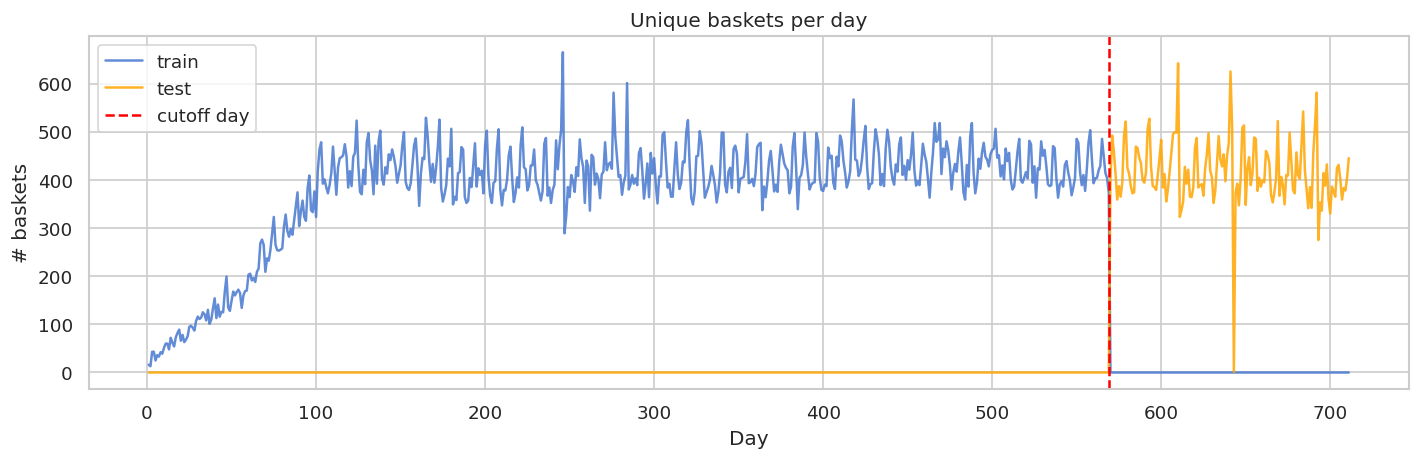

In [ ]:
# Baskets per day coloured by split
basket_day_train = train_df.groupby("day")["basket_id"].nunique().rename("train")
basket_day_test  = test_df.groupby("day")["basket_id"].nunique().rename("test")
basket_day = pd.concat([basket_day_train, basket_day_test], axis=1).fillna(0)

cutoff = int(train_df["day"].max())

fig, ax = plt.subplots(figsize=(12, 4))
basket_day["train"].plot(ax=ax, label="train", alpha=0.85)
basket_day["test"].plot(ax=ax, label="test", color="orange", alpha=0.85)
ax.axvline(cutoff, color="red", linestyle="--", label=f"cutoff day")
ax.set_title("Unique baskets per day")
ax.set_xlabel("Day"); ax.set_ylabel("# baskets")
ax.legend()
plt.tight_layout()

Basket size (train) — mean: 9.18, median: 4, max: 168
Basket size (test)  — mean: 9.76, median: 5, max: 147


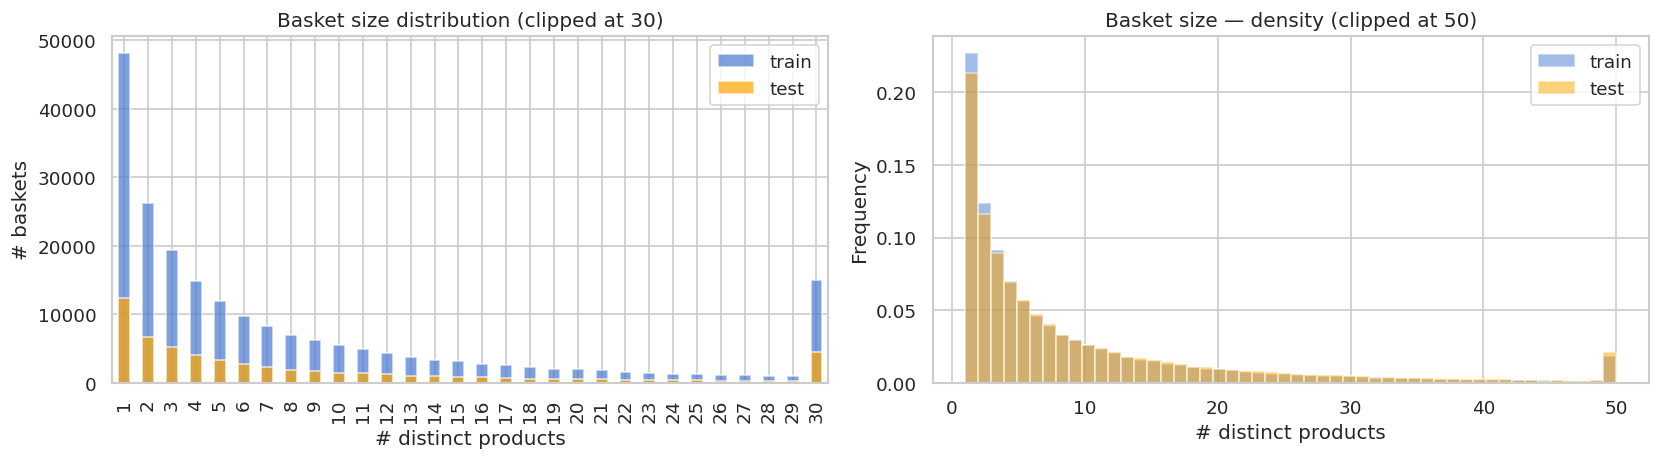

In [25]:
# Basket size distributions
train_sizes = train_df.groupby("basket_id")["product_id"].nunique()
test_sizes  = test_df.groupby("basket_id")["product_id"].nunique()

print(f"Basket size (train) — mean: {train_sizes.mean():.2f}, median: {train_sizes.median():.0f}, max: {train_sizes.max()}")
print(f"Basket size (test)  — mean: {test_sizes.mean():.2f}, median: {test_sizes.median():.0f}, max: {test_sizes.max()}")

clip = 30
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_sizes.clip(upper=clip).value_counts().sort_index().rename("train").plot(kind="bar", ax=axes[0], alpha=0.7)
test_sizes.clip(upper=clip).value_counts().sort_index().rename("test").plot(kind="bar", ax=axes[0], alpha=0.7, color="orange")
axes[0].set_title(f"Basket size distribution (clipped at {clip})")
axes[0].set_xlabel("# distinct products"); axes[0].set_ylabel("# baskets")
axes[0].legend()

train_sizes.clip(upper=50).plot(kind="hist", bins=50, density=True, alpha=0.5, label="train", ax=axes[1])
test_sizes.clip(upper=50).plot(kind="hist", bins=50, density=True, alpha=0.5, label="test", color="orange", ax=axes[1])
axes[1].set_title("Basket size — density (clipped at 50)")
axes[1].set_xlabel("# distinct products")
axes[1].legend()
plt.tight_layout()

In [26]:
# Product coverage: what fraction of test products are seen in train?
train_products = set(train_df["product_id"].unique())
test_products  = set(test_df["product_id"].unique())
both       = train_products & test_products
only_test  = test_products  - train_products
only_train = train_products - test_products

print(f"Products in train:               {len(train_products):,}")
print(f"Products in test:                {len(test_products):,}")
print(f"Products in both:                {len(both):,}  ({100*len(both)/len(test_products):.1f}% of test)")
print(f"Products only in test (unseen):  {len(only_test):,}  ({100*len(only_test)/len(test_products):.1f}% of test)")
print(f"Products only in train (dropped): {len(only_train):,}")

Products in train:               55,529
Products in test:                37,745
Products in both:                34,549  (91.5% of test)
Products only in test (unseen):  3,196  (8.5% of test)
Products only in train (dropped): 20,980


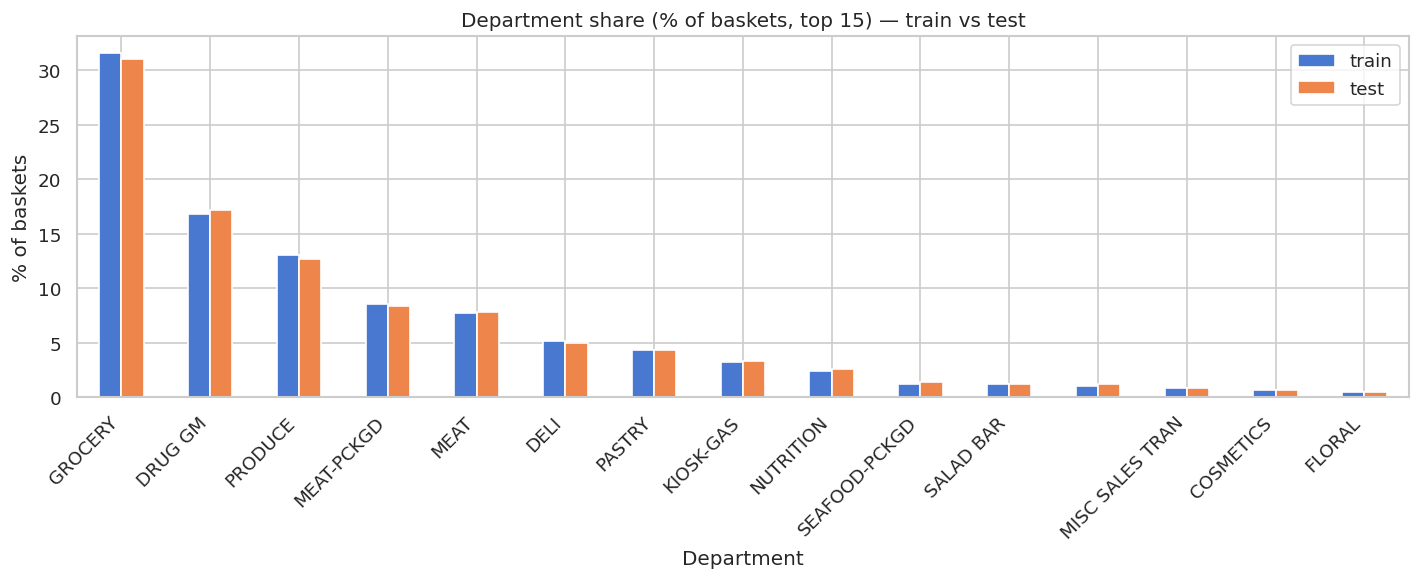

In [27]:
# Department distribution — train vs test (requires product metadata join)
if "department" in train_df.columns:
    train_dept = (
        train_df.drop_duplicates(["basket_id", "department"])
        .groupby("department")["basket_id"].nunique()
    )
    test_dept = (
        test_df.drop_duplicates(["basket_id", "department"])
        .groupby("department")["basket_id"].nunique()
    )
    dept_df = pd.DataFrame({"train": train_dept, "test": test_dept}).fillna(0)
    dept_df = (dept_df.div(dept_df.sum()) * 100).round(2)
    dept_df = dept_df.sort_values("train", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(12, 5))
    dept_df.plot(kind="bar", ax=ax)
    ax.set_title("Department share (% of baskets, top 15) — train vs test")
    ax.set_ylabel("% of baskets"); ax.set_xlabel("Department")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
else:
    print("No 'department' column — skipping category distribution plot.")

Spearman rank correlation (product support, train vs test): 0.8034
Products in common: 34,549


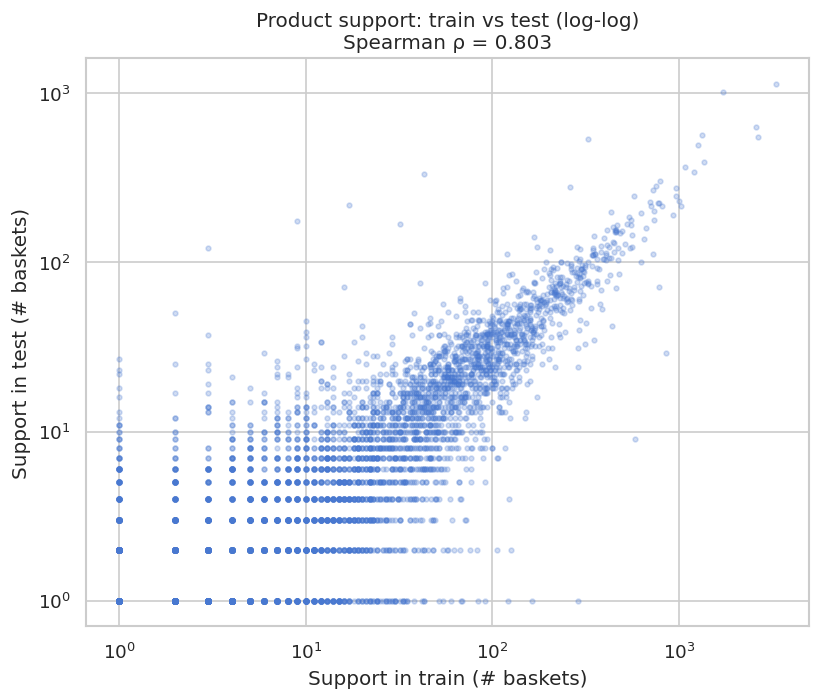

In [28]:
# Product support rank stability: are popular products in train also popular in test?
train_freq = train_df.groupby("product_id")["basket_id"].nunique().rename("train_support")
test_freq  = test_df.groupby("product_id")["basket_id"].nunique().rename("test_support")
common = train_freq.to_frame().join(test_freq, how="inner")

rho = common["train_support"].corr(common["test_support"], method="spearman")
print(f"Spearman rank correlation (product support, train vs test): {rho:.4f}")
print(f"Products in common: {len(common):,}")

sample = common.sample(min(5000, len(common)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample["train_support"], sample["test_support"], alpha=0.25, s=8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title(f"Product support: train vs test (log-log)\nSpearman ρ = {rho:.3f}")
ax.set_xlabel("Support in train (# baskets)")
ax.set_ylabel("Support in test (# baskets)")
plt.tight_layout()